In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
Housing= pd.read_csv(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Housing.csv")
sns.set_theme(style='whitegrid', palette='muted')
BLUE, ORANGE, GREEN, RED = '#2563EB', '#F97316', '#16A34A', '#DC2626'
colors = [BLUE, ORANGE, GREEN, RED, '#7C3AED', '#0891B2']
Housing.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [25]:
#Understanding the data
Housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [26]:
Housing.shape

(545, 13)

In [27]:
Housing.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [28]:
Housing.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

In [29]:
Housing.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [30]:
duplicates = Housing.duplicated().sum()
duplicates

np.int64(0)

In [31]:
Housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


The Housing Dataset Structure and Quality Summary

The  Housing dataset contains 545 records (rows) and 13 features (columns) related to housing characteristics and property prices. The target variable appears to be price, while the remaining columns describe various attributes of the houses, such as area, number of bedrooms, bathrooms, stories, parking spaces, and amenities.

The dataset consists of:


6 numerical variables (price, area, bedrooms, bathrooms, stories, and parking) stored as integer values.


7 categorical variables (mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, and furnishingstatus) stored as text/string values.

A data quality assessment shows that:
1. No missing values were found in any column, indicating a complete dataset.
2. The data types are appropriate for the information represented by each feature.
3. The dataset is well-structured and ready for further analysis and visualization.
4. The combination of numerical and categorical variables provides sufficient information for exploring factors that influence house prices.

Overall, the dataset is of good quality, with no missing data and a clear structure, making it suitable for exploratory data analysis, visualization, and predictive modeling.

In [32]:
Housing

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [33]:
# Correct Data Types 
# Binary yes/no columns → integer (0/1) for numeric operations
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    Housing[col] = Housing[col].map({'yes': 1, 'no': 0})

# Ordinal encode furnishingstatus
furnishing_map = {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}
Housing['furnishingstatus_enc'] = Housing['furnishingstatus'].map(furnishing_map)
Housing.dtypes

price                   int64
area                    int64
bedrooms                int64
bathrooms               int64
stories                 int64
mainroad                int64
guestroom               int64
basement                int64
hotwaterheating         int64
airconditioning         int64
parking                 int64
prefarea                int64
furnishingstatus          str
furnishingstatus_enc    int64
dtype: object

In [34]:
# Saving cleaned dataset
Housing.to_csv(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_2_Housing_project\Housing_Cleaned.csv", index=False)

# Performing Univariate Analysis

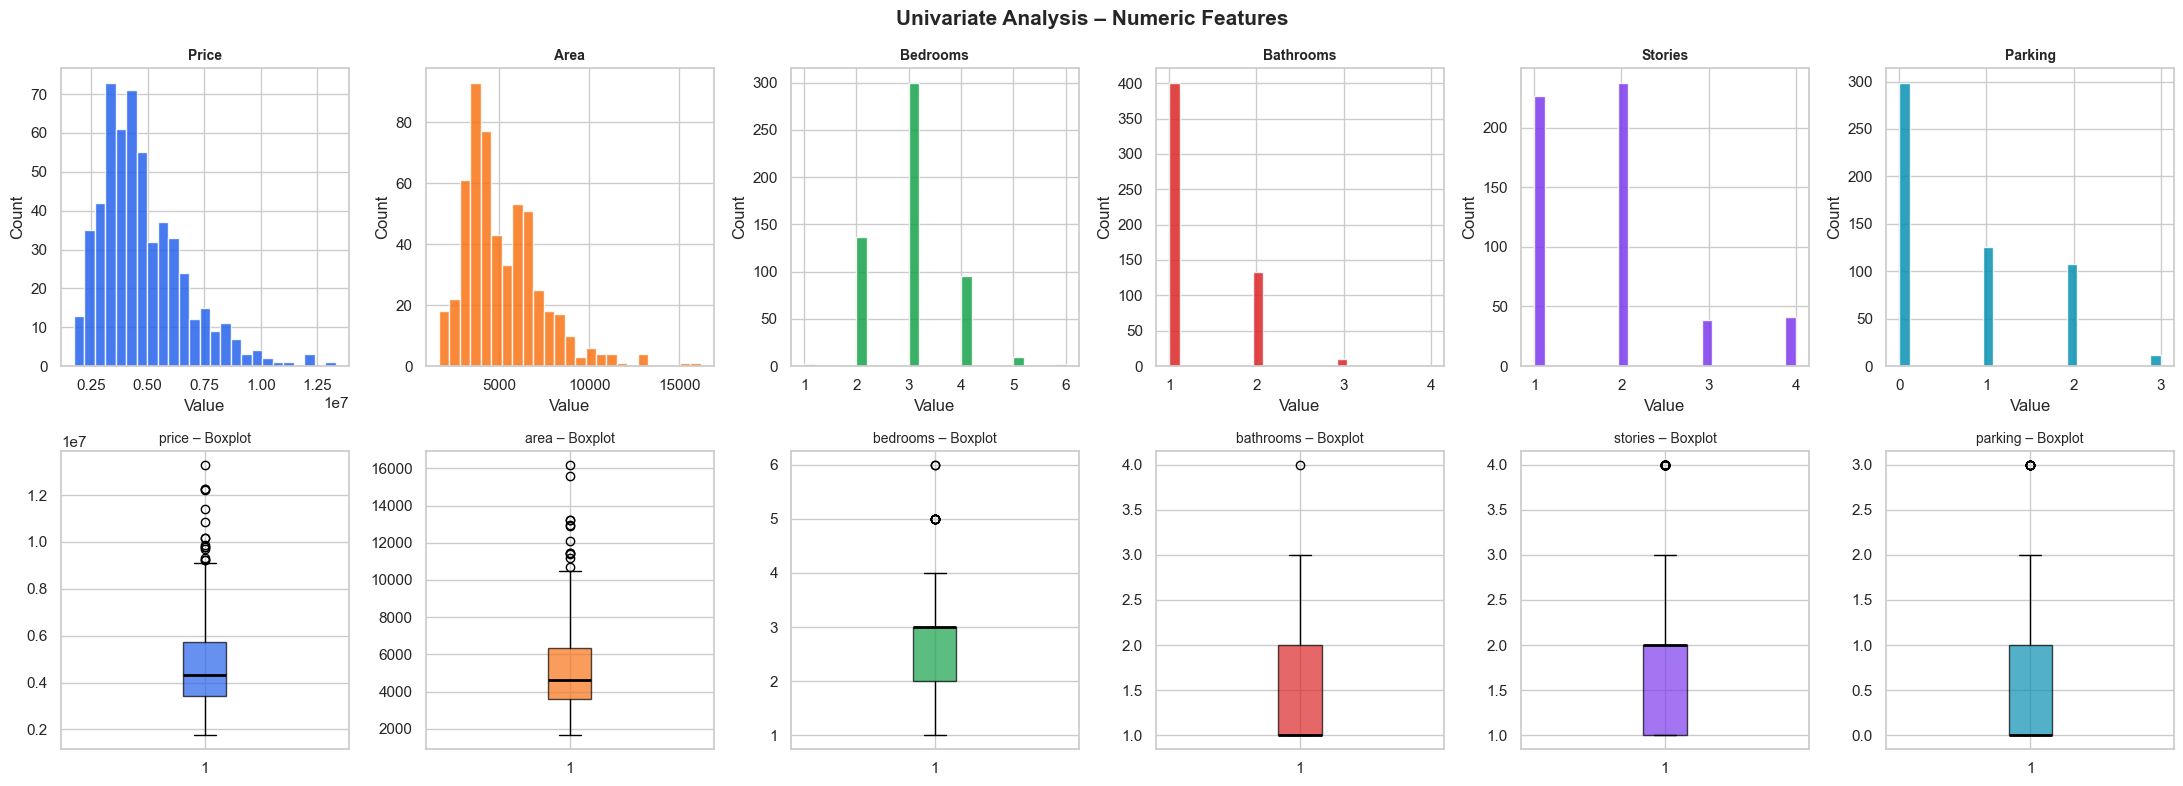

In [35]:

# Histograms & Boxplots for Numeric Features
num_cols = ['price','area','bedrooms','bathrooms','stories','parking']
fig, axes = plt.subplots(2, 6, figsize=(22, 8))
fig.suptitle('Univariate Analysis – Numeric Features', fontsize=15, fontweight='bold')
for i, col in enumerate(num_cols):
    ax1, ax2 = axes[0, i], axes[1, i]
    ax1.hist(Housing[col], bins=25, color=colors[i], edgecolor='white', alpha=0.85)
    ax1.set_title(col.capitalize(), fontsize=10, fontweight='bold')
    ax1.set_xlabel('Value'); ax1.set_ylabel('Count')
    ax2.boxplot(Housing[col], patch_artist=True,
                boxprops=dict(facecolor=colors[i], alpha=0.7),
                medianprops=dict(color='black', linewidth=2))
    ax2.set_title(f'{col} – Boxplot', fontsize=10)

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_2_Housing_project\Housing_EDA01.png",dpi=300,bbox_inches='tight')
plt.show()

In [36]:
# COEFFICIENT OF VARIATION (higher = more variation)
cv_values = {}
for col in num_cols:
    cv_values[col] = (Housing[col].std() / Housing[col].mean()) * 100

cv_Housing = pd.DataFrame.from_dict(cv_values, orient='index', columns=['Coefficient of Variation (%)'])

cv_Housing

,Coefficient of Variation (%)
price,39.239477
area,42.134232
bedrooms,24.891386
bathrooms,39.065041
stories,48.047093
parking,124.223342


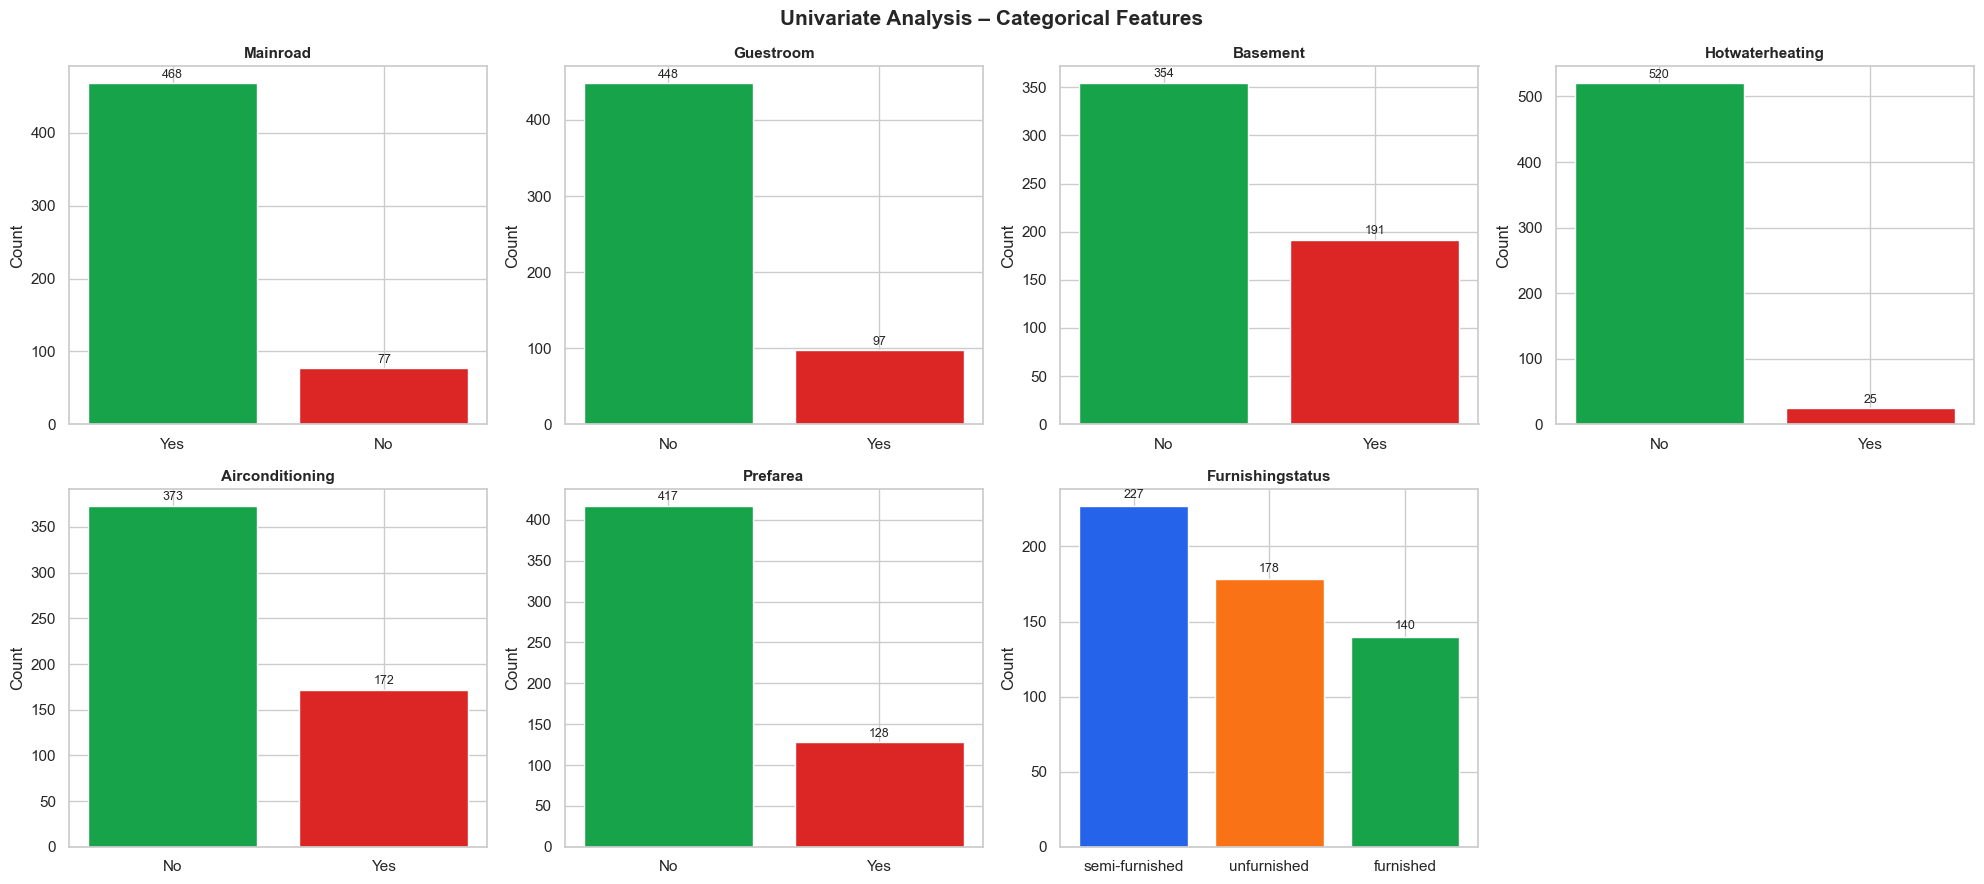

In [37]:
cat_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Univariate Analysis – Categorical Features', fontsize=15, fontweight='bold')
axes_flat = axes.flatten()
for i, col in enumerate(cat_cols):
    ax = axes_flat[i]
    if col == 'furnishingstatus':
        vc = Housing[col].value_counts()
        ax.bar(vc.index, vc.values, color=colors[:3], edgecolor='white')
    else:
        vc = Housing[col].value_counts()
        labels = ['Yes' if x==1 else 'No' for x in vc.index]
        ax.bar(labels, vc.values, color=[GREEN, RED], edgecolor='white')
    ax.set_title(col.replace('_',' ').title(), fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    for bar in ax.patches:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_2_Housing_project\Housing_EDA02.png",dpi=300,bbox_inches='tight')
plt.show()

# Bivariate Analysis

C:\Users\ThePhantomTrader\AppData\Local\Temp\ipykernel_13988\3992997769.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(ac_data, patch_artist=True, labels=['No AC','With AC'], medianprops=dict(color='black', linewidth=2))
C:\Users\ThePhantomTrader\AppData\Local\Temp\ipykernel_13988\3992997769.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=['Unfurnished','Semi','Furnished'], medianprops=dict(color='black', linewidth=2))


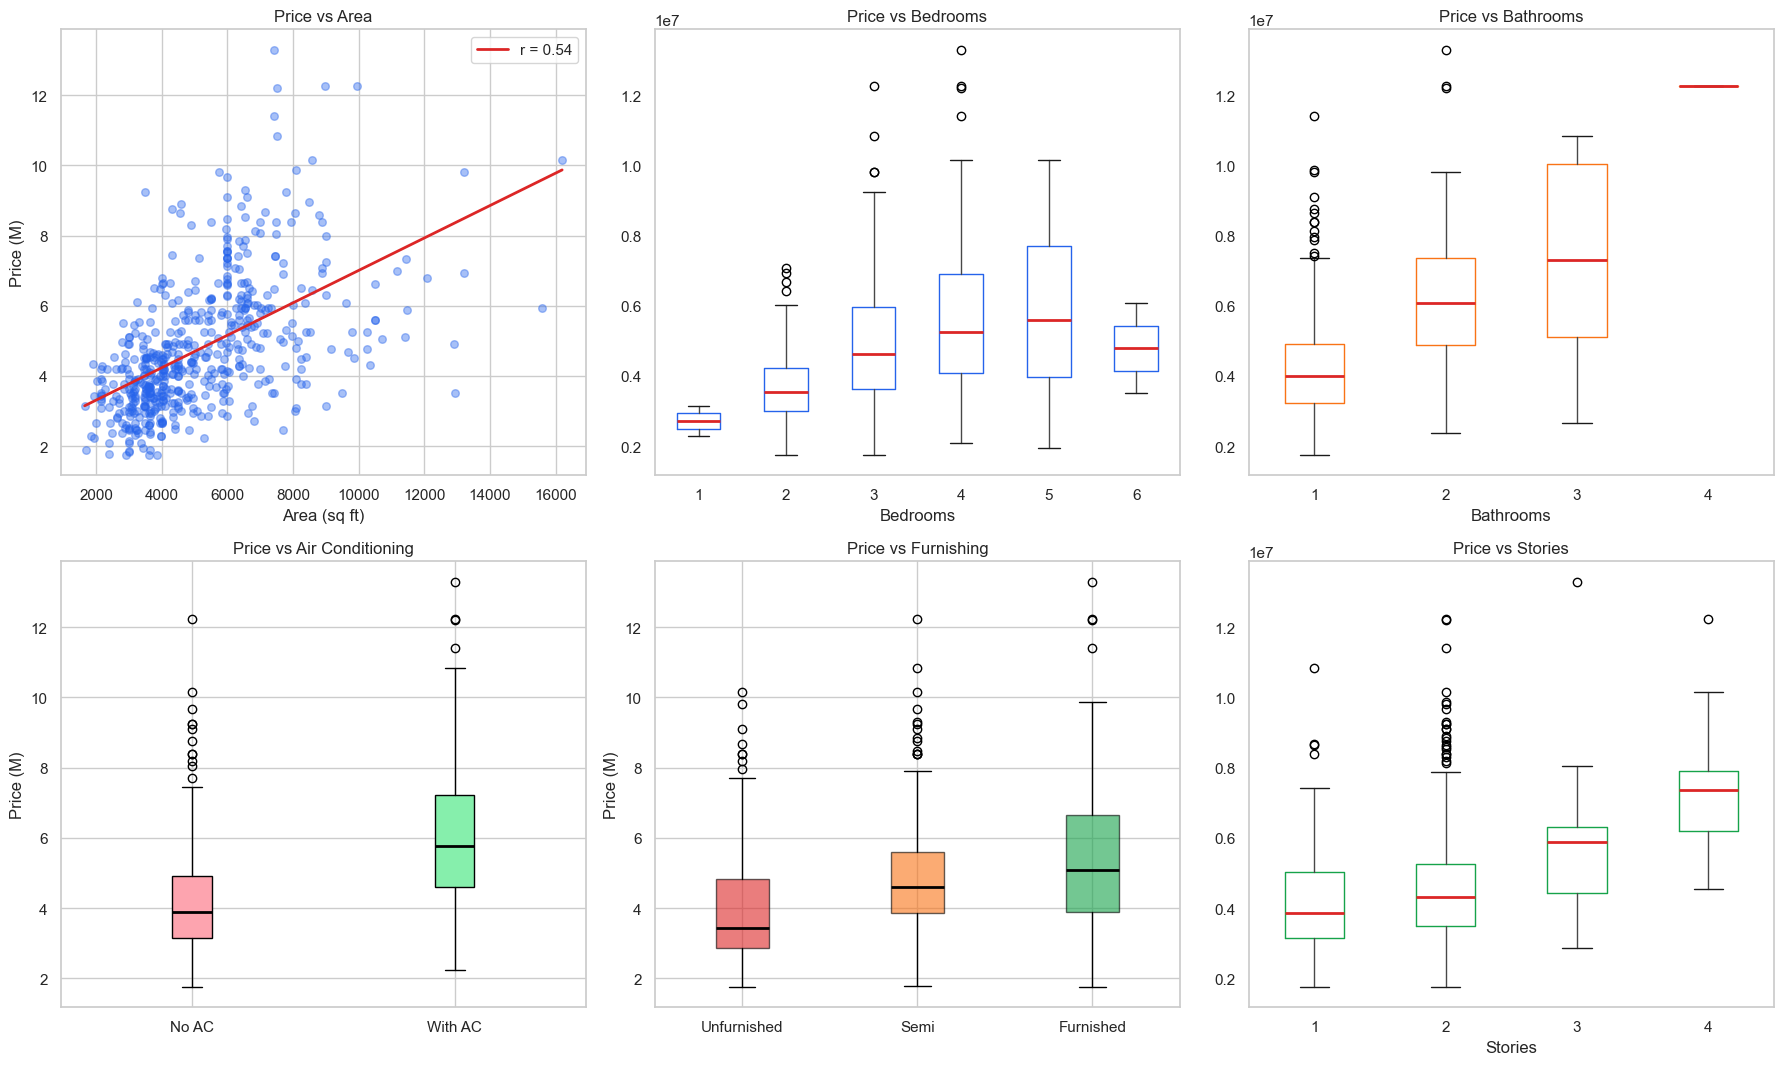

In [38]:


#  Price vs Key Features 
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Bivariate Analysis – Price vs Key Features', fontsize=15, fontweight='bold')

# Price vs Area scatter with trendline
ax = axes[0,0]
ax.scatter(Housing['area'], Housing['price']/1e6, alpha=0.4, color=BLUE, s=30)
m, b = np.polyfit(Housing['area'], Housing['price']/1e6, 1)
xr = np.linspace(Housing['area'].min(), Housing['area'].max(), 200)
r = Housing['area'].corr(Housing['price'])
ax.plot(xr, m*xr+b, color=RED, linewidth=2, label=f'r = {r:.2f}')
ax.set_xlabel('Area (sq ft)'); ax.set_ylabel('Price (M)'); ax.set_title('Price vs Area'); ax.legend()

# Price vs Bedrooms
Housing.boxplot(column='price', by='bedrooms', ax=axes[0,1], grid=False,
           boxprops=dict(color=BLUE), medianprops=dict(color=RED, linewidth=2))
axes[0,1].set_title('Price vs Bedrooms'); axes[0,1].set_xlabel('Bedrooms'); plt.sca(axes[0,1]); plt.suptitle('')

# Price vs Bathrooms
Housing.boxplot(column='price', by='bathrooms', ax=axes[0,2], grid=False,
           boxprops=dict(color=ORANGE), medianprops=dict(color=RED, linewidth=2))
axes[0,2].set_title('Price vs Bathrooms'); axes[0,2].set_xlabel('Bathrooms'); plt.sca(axes[0,2]); plt.suptitle('')

# Price vs AC
ax = axes[1,0]
ac_data = [Housing[Housing['airconditioning']==0]['price']/1e6, Housing[Housing['airconditioning']==1]['price']/1e6]
bp = ax.boxplot(ac_data, patch_artist=True, labels=['No AC','With AC'], medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#FDA4AF'); bp['boxes'][1].set_facecolor('#86EFAC')
ax.set_title('Price vs Air Conditioning'); ax.set_ylabel('Price (M)')

# Price vs Furnishing
ax = axes[1,1]
order = ['unfurnished','semi-furnished','furnished']
data = [Housing[Housing['furnishingstatus']==s]['price']/1e6 for s in order]
bp = ax.boxplot(data, patch_artist=True, labels=['Unfurnished','Semi','Furnished'], medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], [RED, ORANGE, GREEN]): patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_title('Price vs Furnishing'); ax.set_ylabel('Price (M)')

# Price vs Stories
Housing.boxplot(column='price', by='stories', ax=axes[1,2], grid=False,
           boxprops=dict(color=GREEN), medianprops=dict(color=RED, linewidth=2))
axes[1,2].set_title('Price vs Stories'); axes[1,2].set_xlabel('Stories'); plt.sca(axes[1,2]); plt.suptitle('')

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_2_Housing_project\Housing_EDA03.png",dpi=300,bbox_inches='tight')
plt.show()

# Correlation & Feature Importance

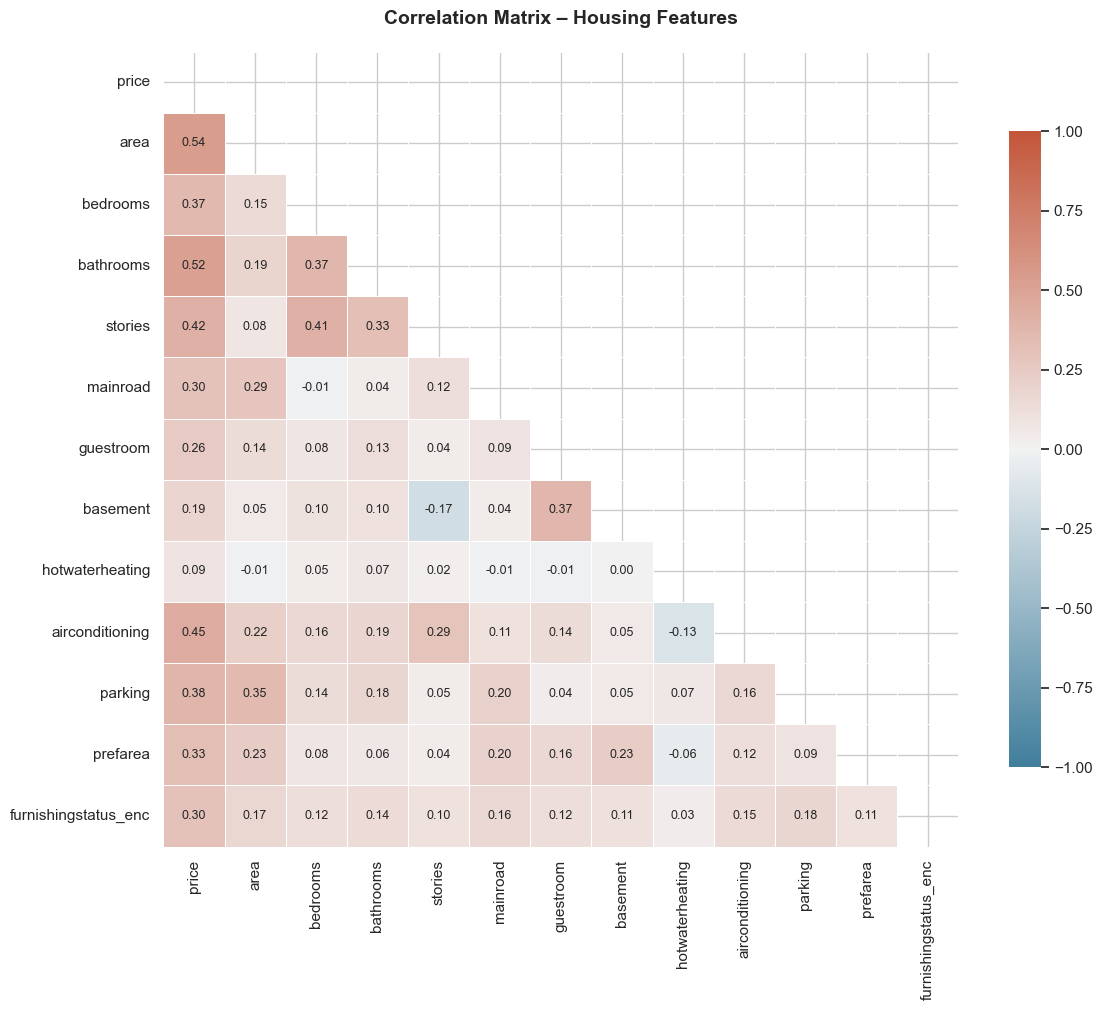

In [42]:
 #Correlation Matrix & Heatmap 
num_Housing = Housing.drop(columns=['furnishingstatus'])
corr = num_Housing.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'shrink': .8}, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Matrix – Housing Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_2_Housing_project\Housing_EDA04.png",dpi=300,bbox_inches='tight')
plt.show()

# Feature Importance Ranking 

Feature correlation with Price (absolute):
area                    0.535997
bathrooms               0.517545
airconditioning         0.452954
stories                 0.420712
parking                 0.384394
bedrooms                0.366494
prefarea                0.329777
furnishingstatus_enc    0.304721
mainroad                0.296898
guestroom               0.255517
basement                0.187057
hotwaterheating         0.093073


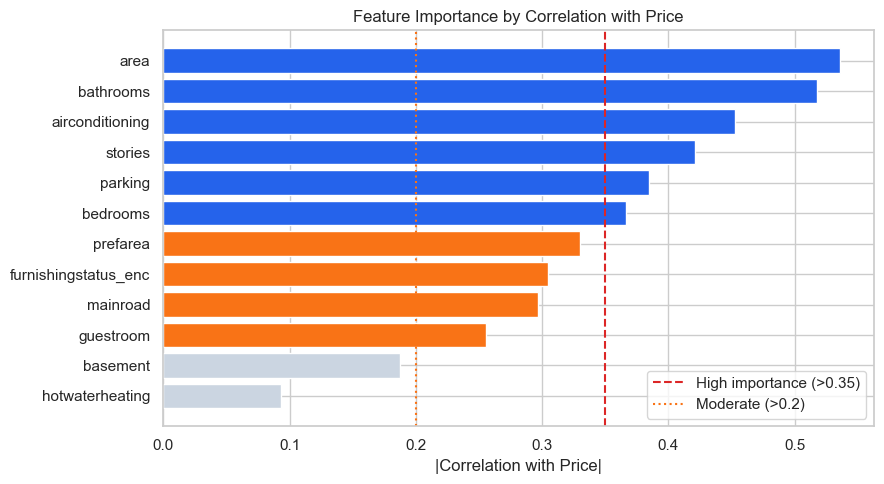

In [43]:

price_corr = corr['price'].drop('price').abs().sort_values(ascending=False)
print('Feature correlation with Price (absolute):')
print(price_corr.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(price_corr.index[::-1], price_corr.values[::-1],
               color=[BLUE if v > 0.35 else ORANGE if v > 0.2 else '#CBD5E1' for v in price_corr.values[::-1]])
ax.axvline(0.35, color=RED, linestyle='--', linewidth=1.5, label='High importance (>0.35)')
ax.axvline(0.2, color=ORANGE, linestyle=':', linewidth=1.5, label='Moderate (>0.2)')
ax.set_xlabel('|Correlation with Price|')
ax.set_title('Feature Importance by Correlation with Price')
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_2_Housing_project\Housing_EDA05.png",dpi=300,bbox_inches='tight')
plt.show()

Key Insights

Insight 1: 

House size (area) is the biggest factor affecting price (r = 0.54)
There is a clear relationship between house size and price. Bigger houses tend to be significantly more expensive, especially those above 8,000 sq ft. This shows that space is the main thing buyers pay for.

Insight 2: 

Bathrooms matter more than bedrooms (r = 0.52 vs 0.37)
Interestingly, bathrooms have a stronger effect on price than bedrooms. Homes with more bathrooms tend to be much more expensive, which suggests buyers value comfort and convenience more than just room count.

Insight 3: 

Air conditioning increases property value (r = 0.45)
Homes with air conditioning are generally priced higher. This makes sense since AC is an important comfort feature, especially in warmer climates, and is treated as a premium addition.

Insight 4: 

More floors and parking spaces increase price
Multi-story houses tend to cost more, likely because they are larger overall. Also, homes with more parking spaces are slightly more expensive, showing that parking convenience adds value for buyers.

Insight 5: 

Hot water heating has almost no impact (r = 0.09)
This feature has very little relationship with price. It doesn’t really influence how houses are valued, so it may not be useful for prediction models.

Insight 6: 

Furnishing status has a moderate effect
Fully furnished homes generally sell for higher prices compared to unfurnished ones. However, semi-furnished homes are not very different from unfurnished ones, meaning buyers mostly care about whether a home is fully furnished or not.

Insight 7: 

High-priced homes are not errors
Some homes in the dataset are very expensive (above ₹10M). These are not mistakes — they are large luxury houses with bigger space, more bathrooms, air conditioning, and better locations.

Feature Importance Summary for ML
| Tier | Features |
|------|----------|
| High importance | area, bathrooms, airconditioning, stories |
| Moderate importance | parking, bedrooms, prefarea, furnishing |
| Low importance | mainroad, guestroom, basement, hotwaterheating |

Overall, house price is mainly driven by size and comfort features. Space (area), number of bathrooms, and air conditioning are the strongest factors, while some features like heating and basement have very little influence on pricing.
